# Trabalho Computacional 10
## PPGEE 2166 Processos Estocásticos (2026.1)
- Discente: Thiago Tomás de Paula (242104677)
- Data: 15/07/2026

### Item 10.1 

Idêntico ao Trabalho 7, só que agora você deve usar o arquivo `Data_Alzheimer_Diagnosis.csv`.

---

### Análise exploratória dos dados

Esta etapa do estudo gera e analisa os seguintes itens:

0. retrato de dados faltantes ou indefinidos;
1. listagem das classes: nomes, descrições e unidades;
2. listagem das features: nomes, descrições e unidades;
3. gráficos de dispersões e histogramas das features;
4. matriz de correlação de Pearson entre as features desconsiderando classes;
5. matriz de correlação de Pearson entre as features por cada classe. 

**Carregamento dos dados.**

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Estilo para os gráficos
COLORMAP = "Set1"
sns.set_style('whitegrid')
sns.set_palette(COLORMAP)
plt.set_cmap(COLORMAP)

# Guarda os dados do arquivo CSV em um DataFrame do Pandas
caminho_dos_dados = "Data_Alzheimer_Diagnosis.csv"
dados = pd.read_csv(caminho_dos_dados)
COLUNA_CLASSE = "diagnosis"

# Renomeia classes: {0: "Saudável", 1: "Alzheimer"}
dados[COLUNA_CLASSE] = dados[COLUNA_CLASSE].map({0: "Saudável", 1: "Alzheimer"})

<Figure size 640x480 with 0 Axes>

**Checagem dos dados.** 

A rigor, o dataset é completamente anonimizado, tornando incerta qualquer interpretação.
Dado o nome do arquivo, supõe-se que 
o dataset é uma coleção de dados de pacientes que fizeram um exame de detecção de Alzheimer.
Cada uma das 820 linhas do dataset é o registro de uma paciente, 
e cada uma das 30 colunas um tipo registro sobre o câncer da paciente.
Uma destas colunas, `diagnosis`, informa o resultado do exame, entre presença de Alzheimer (1) ou saudável (0).

A figura abaixo mostra que não há dados faltantes/indefinidos para nenhuma entrada no dataset.

<Axes: >

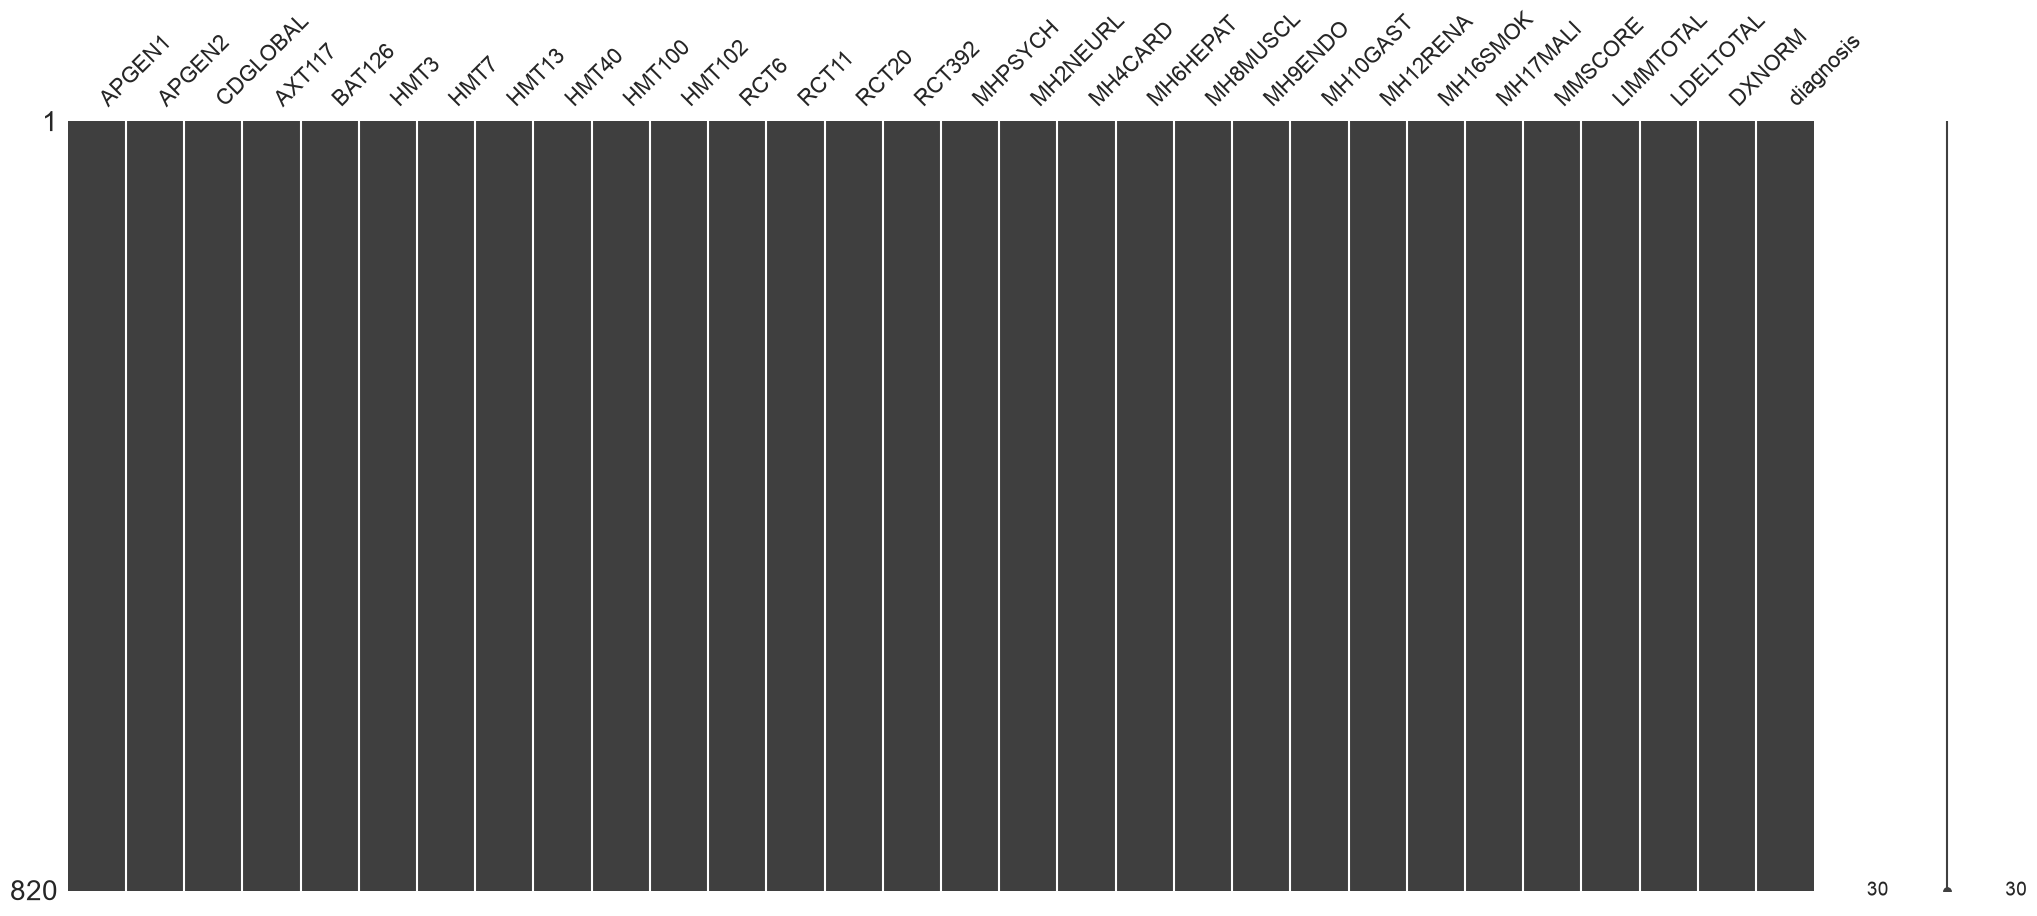

In [3]:
# 0. retrato de dados faltantes ou indefinidos
import missingno as msno
msno.matrix(dados)

**Classes.**

A coluna `diagnosis` possui dois valores, 0 para diagnóstico de ausência de Alzheimer e 1 para presença de Alzheimer. 

Dos 820 casos, 592 (72.2%) são Alzheimer, e 228 (27.8%) são saudáveis, revelando o dataset como relativamente desbalanceado com viés para casos de Alzheimer.

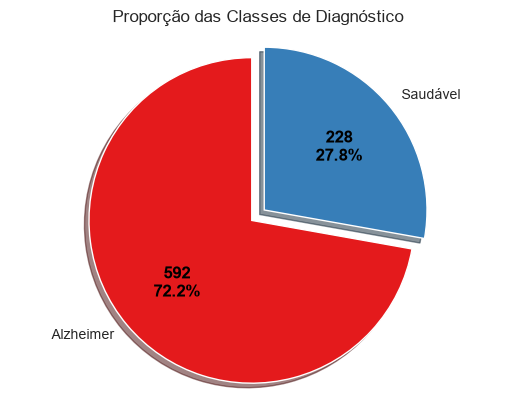

In [6]:
# 1. listagem das classes: nomes, descrições e unidades. 
## Proporção das classes em % com 2 casas decimais
def plotar_proporcao_classes(dados, coluna_classe=COLUNA_CLASSE, colormap=COLORMAP, titulo="Proporção das Classes de Diagnóstico", ax=None):
    _valores_proporcionais = dados[coluna_classe].value_counts(normalize=True).mul(100).round(2)
    _valores_absolutos = dados[coluna_classe].value_counts()
    _df_classes = pd.DataFrame({
        "Classe": _valores_absolutos.index, 
        "Quantidade": _valores_absolutos.values, 
        "Proporção (%)": _valores_proporcionais.values
    })

    # Gráfico de pizza para visualização da proporção e quantidade das classes
    if ax is None:
        _, ax = plt.subplots()
    pie = ax.pie(_df_classes["Quantidade"], labels=_df_classes["Classe"], shadow=True, startangle=90, explode=(0.1, 0))
    _ = ax.pie_label(pie, '{absval:d}\n{frac:.1%}', textprops={'fontsize': 'large', 'color': 'black', 'weight': 'bold'})
    _ = ax.set_title(titulo)
    _ = plt.axis('equal')

plotar_proporcao_classes(dados)

**Features.**

O dataset possui 29 features ao todo. O significado dos valores numéricos é incerto, mas todas as features parecem estar relacionadas ao genoma do paciente, sejam elas categóricas ou numéricas.

Fica claro que existem algumas features com boa separação de classes em relação a outras features, mas na maioria dos casos as dispersões são indistinguíveis entre as classes, o que pode dificultar a classificação.

**Dispersões e histogramas.** 

Abaixo, mostram-se os gráficos de dispersão e histogramas das features numéricas.

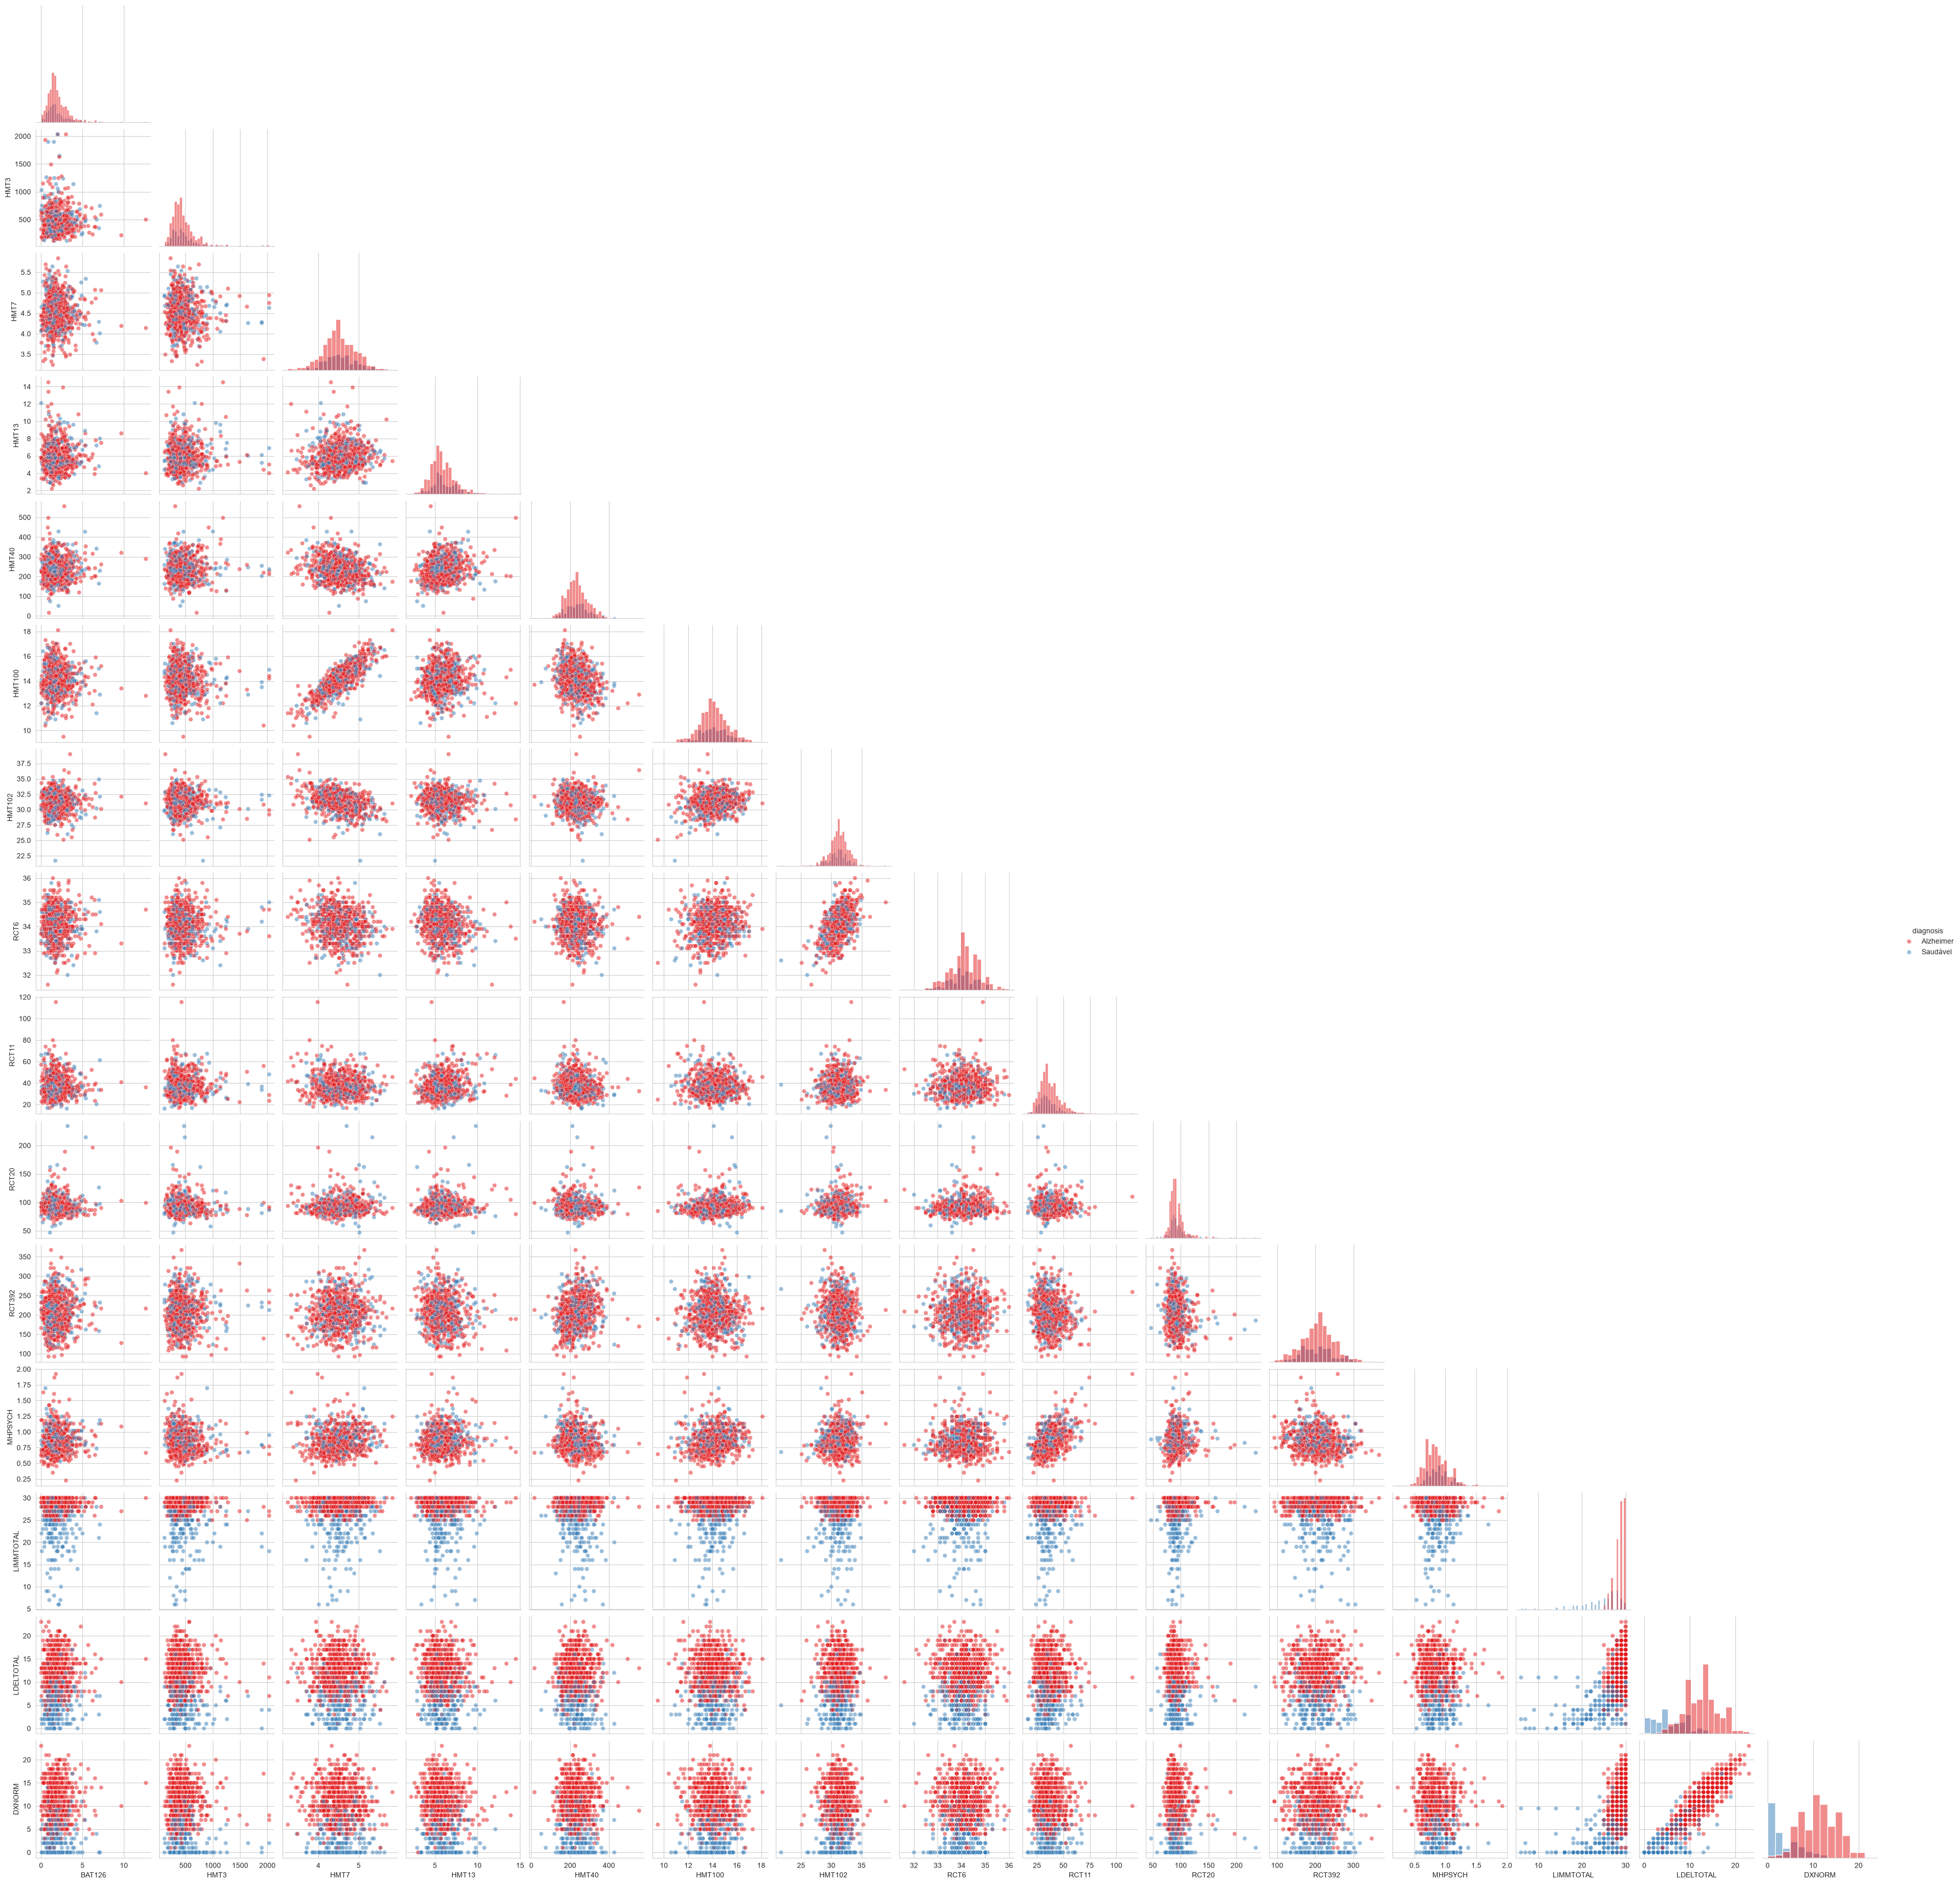

In [15]:
# 3. gráficos de dispersões e histogramas das features
FEATURES_NUMERICAS = ["BAT126","HMT3","HMT7","HMT13","HMT40","HMT100","HMT102","RCT6","RCT11","RCT20","RCT392","MHPSYCH", "LIMMTOTAL","LDELTOTAL","DXNORM"]
sns.pairplot(dados[FEATURES_NUMERICAS + [COLUNA_CLASSE]], hue_order=["Alzheimer", "Saudável"], corner=True, hue=COLUNA_CLASSE, diag_kind='hist', plot_kws={'alpha': 0.5})

**Correlações.**

As matrizes de correlação de Pearson entre as features é apresentada a seguir. 
Ao todo, são desenhadas duas matrizes: 
1. uma considerando todas as amostras de cada feature;
2. uma mostrando a diferença entre as correlações de amostras com tumor e sem tumor.

A primeira matriz mostra que a grande maioria das features são fracamente correlacionadas, o que é boa notícia para os modelos que precisam inverter essa matriz.

<Axes: >

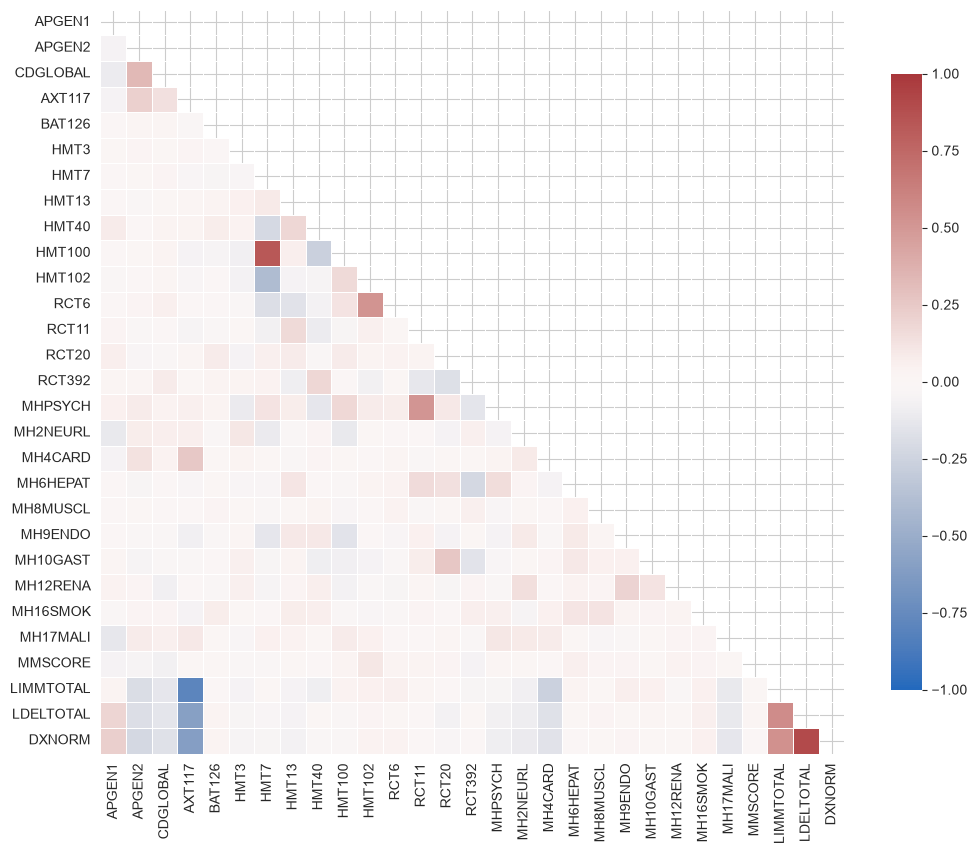

In [23]:
# 4. matriz de correlação de Pearson entre as features desconsiderando classes
import numpy as np
plt.figure(figsize=(12, 10))
matriz_correlacao = dados.drop([COLUNA_CLASSE], axis=1).corr(method='pearson')
mascara_triangular = np.triu(np.ones_like(matriz_correlacao, dtype=bool))
sns.heatmap(matriz_correlacao, vmin=-1, vmax=1, cmap="vlag", square=True, cbar_kws={"shrink": .8}, linewidths=.5, mask=mascara_triangular)

A diferença da matriz de correlação das classes é mostrada abaixo. 

Nota-se que a presença de Alzheimer não altera significativamente a correlação entre as features, com exceção do par
`LIMMTOTAL` e `AXT117`.

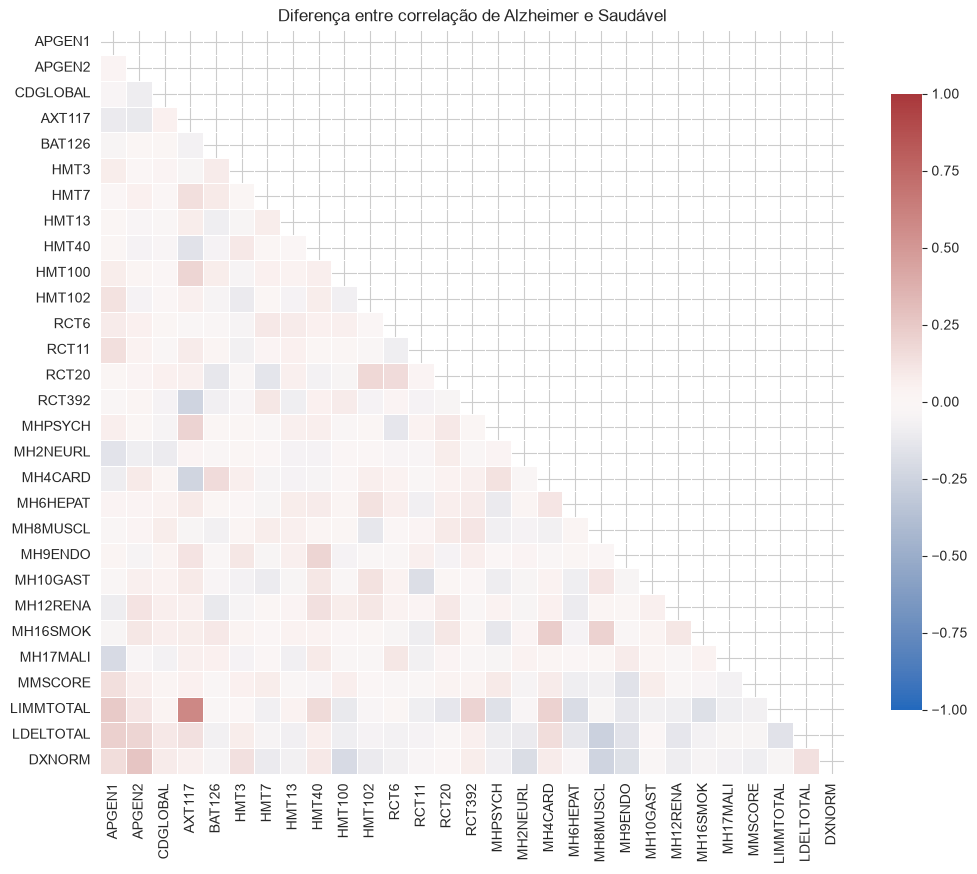

In [25]:
# Calcula a matriz de correlação de Pearson entre as features por cada classe, subtrai uma da outra e plota o resultado em um heatmap
plt.figure(figsize=(12, 10))
mc_maligno = dados[dados[COLUNA_CLASSE] == "Alzheimer"].drop([COLUNA_CLASSE], axis=1).corr(method='pearson')
mc_benigno = dados[dados[COLUNA_CLASSE] == "Saudável"].drop([COLUNA_CLASSE], axis=1).corr(method='pearson')
mc_diferenca = mc_maligno - mc_benigno
sns.heatmap(mc_diferenca, vmin=-1, vmax=1, fmt=".2f", cmap="vlag", square=True, cbar_kws={"shrink": .8}, linewidths=.5, mask=mascara_triangular)
_ = plt.title("Diferença entre correlação de Alzheimer e Saudável")

### Comparação de performance em apenas um caso

Terminada a análise exploratória, as amostras do dataset são preparadas para classificação.

A preparação consiste em dois passos: o embaralhamento de amostras, e a partição das amostras treino (80%) e teste (20%).

In [26]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(dados.drop([COLUNA_CLASSE], axis=1), dados[COLUNA_CLASSE], test_size=0.2, random_state=42, shuffle=True)

A seguir, o conjunto de treino é usado para contruir três classificadores baseados em discriminante da literatura de aprendizagem supervisionada:
- Naïve Bayes
- Linear Discriminant Analysis (LDA)
- Quadratic Discriminant Analysis (QDA)

In [27]:
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

naive_bayes = GaussianNB()
lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis()

naive_bayes.fit(x_train, y_train)
lda.fit(x_train, y_train)
qda.fit(x_train, y_train)

,"solver solver: {'svd', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter. Enabling shrinkage is expected to improve the model when some classes have a relatively small number of training data points compared to the number of features by mitigating overfitting during the covariance estimation step.This should be left to `None` if `covariance_estimator` is used.Note that shrinkage works only with 'eigen' solver.",None
,"priors priors: array-like of shape (n_classes,), default=NoneClass priors. By default, the class proportions are inferred from thetraining data.",None
,"reg_param reg_param: float, default=0.0Regularizes the per-class covariance estimates by transforming S2 as``S2 = (1 - reg_param) * S2 + reg_param * np.eye(n_features)``,where S2 corresponds to the `scaling_` attribute of a given class.",0.0
,"store_covariance store_covariance: bool, default=FalseIf True, the class covariance matrices are explicitly computed andstored in the `self.covariance_` attribute... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for the covariance matrix to be considered rankdeficient after applying some regularization (see `reg_param`) to each`Sk` where `Sk` represents covariance matrix for k-th class. Thisparameter does not affect the predictions. It controls when a warningis raised if the covariance matrix is not full rank... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimate the covariancematrices instead of relying on the empirical covariance estimator(with potential shrinkage). The object should have a fit method anda ``covariance_`` attribute like the estimators in:mod:`sklearn.covariance`. If None the shrinkage parameter drives theestimate.This should be left to `None` if `shrinkage` is used.Note that `covariance_estimator` works only with the 'eigen' solver.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Unique class labels.","ndarray[object](2,)","['Alzheimer','Saudável']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](29,)","['APGEN1','APGEN2','CDGLOBAL',...,'LIMMTOTAL','LDELTOTAL','DXNORM']"
"means_ means_: array-like of shape (n_classes, n_features)Class-wise means.","ndarray[float64](2, 29)","[[423.5 , 3.27, 2.89,..., 28.74, 12.73, 11.37], [367.24, 3.55, 3.01,..., 23.92, 5.62, 3.17]]"


Aqui, os modelos treinados são aplicados no conjunto de teste.

In [28]:
naive_bayes_predicoes = naive_bayes.predict(x_test)
lda_predicoes = lda.predict(x_test)
qda_predicoes = qda.predict(x_test)

Para fins de análise de desempenho, são calculadas as acurácias, os valores de F1, e exibidas as matrizes de confusão de cada modelo.

Matrizes relativas são normalizadas pela linha da matriz, i.e., a quantidade de elementos da classe verdadeira.

Nesta configuração, a diagonal da matriz são as taxas de verdadeiros positivos, e os elementos na diagonal secundária, as de falsos negativos/positivos.

A classe positiva é a de presença de Alzheimer, e a negativa, a de ausência de Alzheimer.

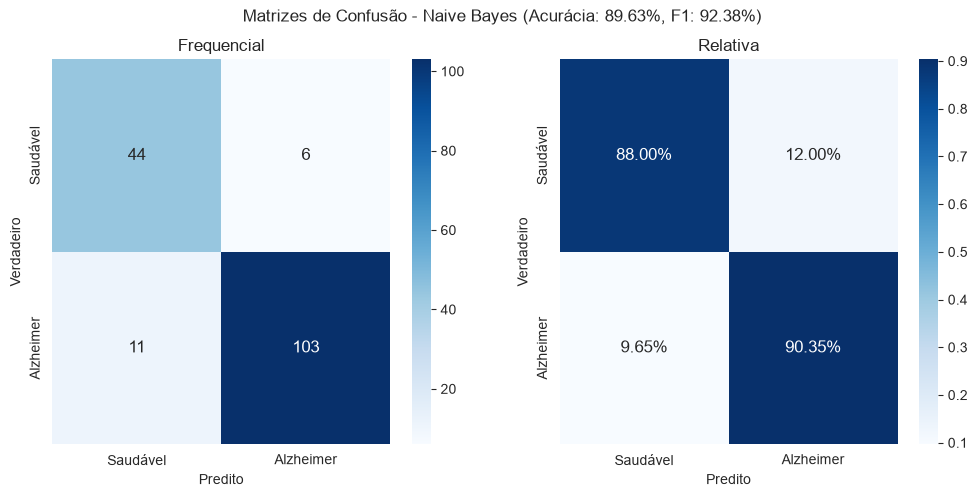

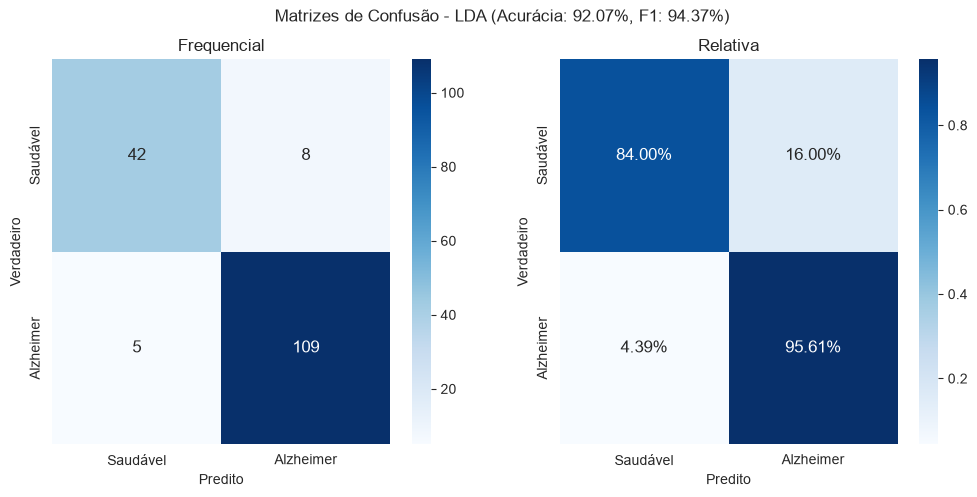

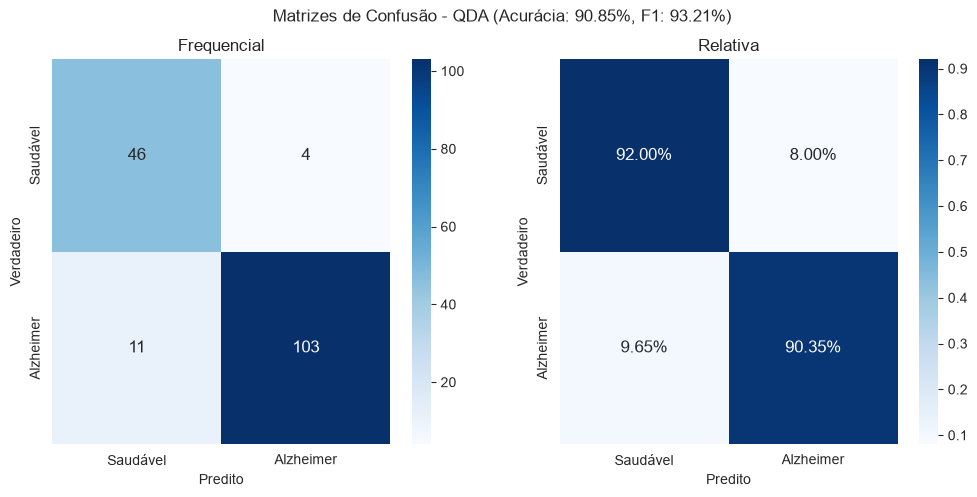

In [29]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

naive_bayes_acuracia = accuracy_score(y_test, naive_bayes_predicoes)
lda_acuracia = accuracy_score(y_test, lda_predicoes)
qda_acuracia = accuracy_score(y_test, qda_predicoes)

naive_bayes_f1 = f1_score(y_test, naive_bayes_predicoes, pos_label="Alzheimer")
lda_f1 = f1_score(y_test, lda_predicoes, pos_label="Alzheimer")
qda_f1 = f1_score(y_test, qda_predicoes, pos_label="Alzheimer")

def plota_matriz_confusao(y_true, y_pred, classes, titulo="Matrizes de Confusão"):
    cm_abs = confusion_matrix(y_true, y_pred, labels=classes)
    cm_rel = confusion_matrix(y_true, y_pred, labels=classes, normalize='true')
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
    hmap_args = {
        "annot": True,
        "cmap": "Blues",
        "xticklabels": classes,
        "yticklabels": classes,
        "annot_kws": {"size": 12}
    }
    sns.heatmap(cm_abs, fmt='d', ax=ax[0], **hmap_args)
    sns.heatmap(cm_rel, fmt='.2%', ax=ax[1], **hmap_args)
    _ = ax[0].set_xlabel('Predito')
    _ = ax[0].set_ylabel('Verdadeiro')
    _ = ax[0].set_title('Frequencial')
    _ = ax[1].set_xlabel('Predito')
    _ = ax[1].set_ylabel('Verdadeiro')
    _ = ax[1].set_title('Relativa')
    fig.suptitle(titulo)

for modelo, acc, f1, preds in [
    ("Naive Bayes", naive_bayes_acuracia, naive_bayes_f1, naive_bayes_predicoes), 
    ("LDA", lda_acuracia, lda_f1, lda_predicoes), 
    ("QDA", qda_acuracia, qda_f1, qda_predicoes)
]:
    plota_matriz_confusao(
        y_test, 
        preds, 
        classes=["Saudável", "Alzheimer"], 
        titulo=f"Matrizes de Confusão - {modelo} (Acurácia: {acc:.2%}, F1: {f1:.2%})"
    )

Vê-se que todos os modelos obtiveram bons resultados, com o LDA se saindo um pouco melhor que os demais em termos de acurácia, F1, falso negativo, e verdadeiro positivo.

Resta verificar se este nível de desempenho dos classificadores, e a diferença entre eles, é estatisticamente representativa. 

### Comparação de performance média

No item anterior, a semente aletória do embaralhamento de amostras foi fixado. 
Aqui, ele assume 10 valores distintos, para os quais o processo de treino, teste e avaliação é repetido. 
Ao final, são apresentados os valores médios das métricas (acurácia, matriz de confusão, F1).

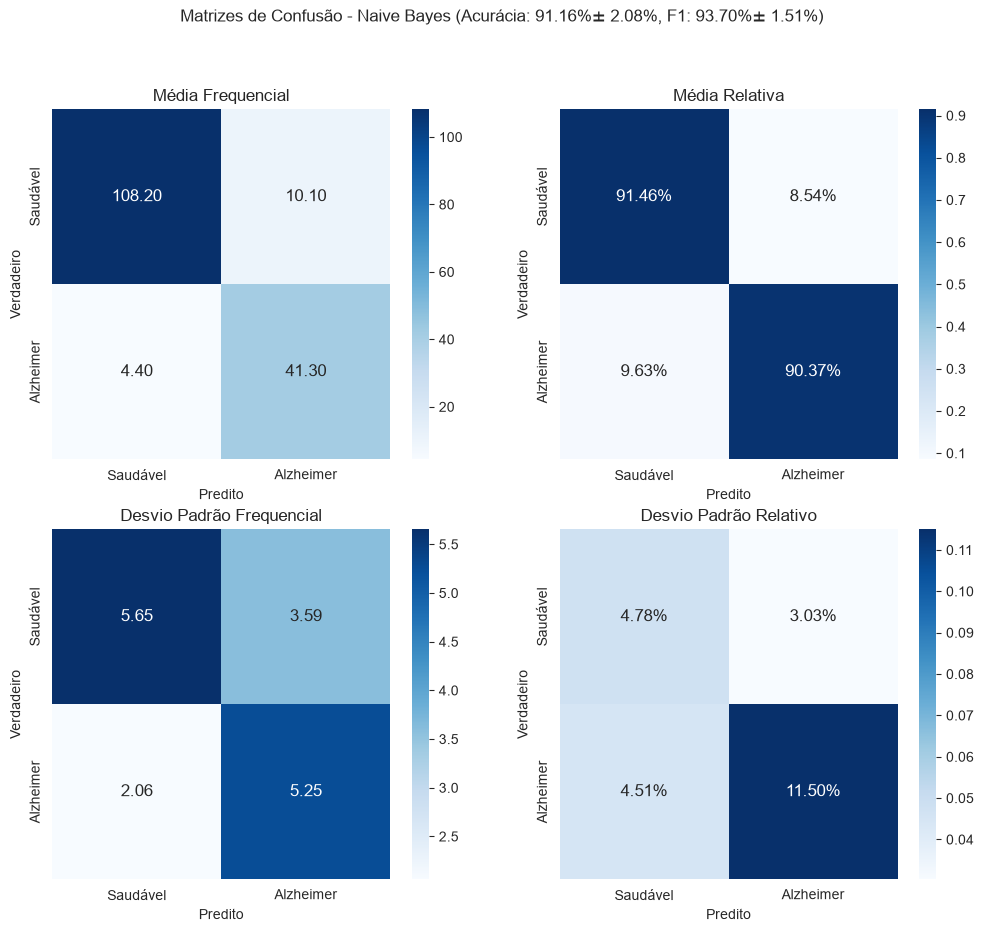

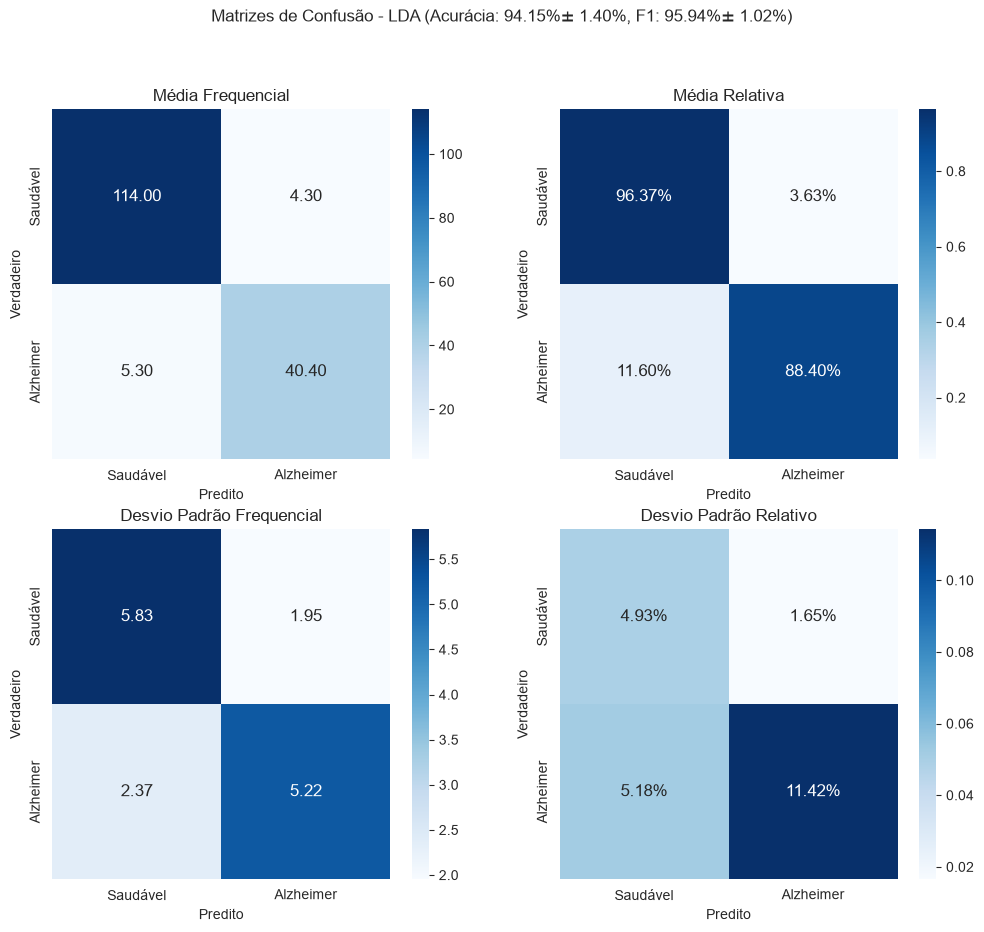

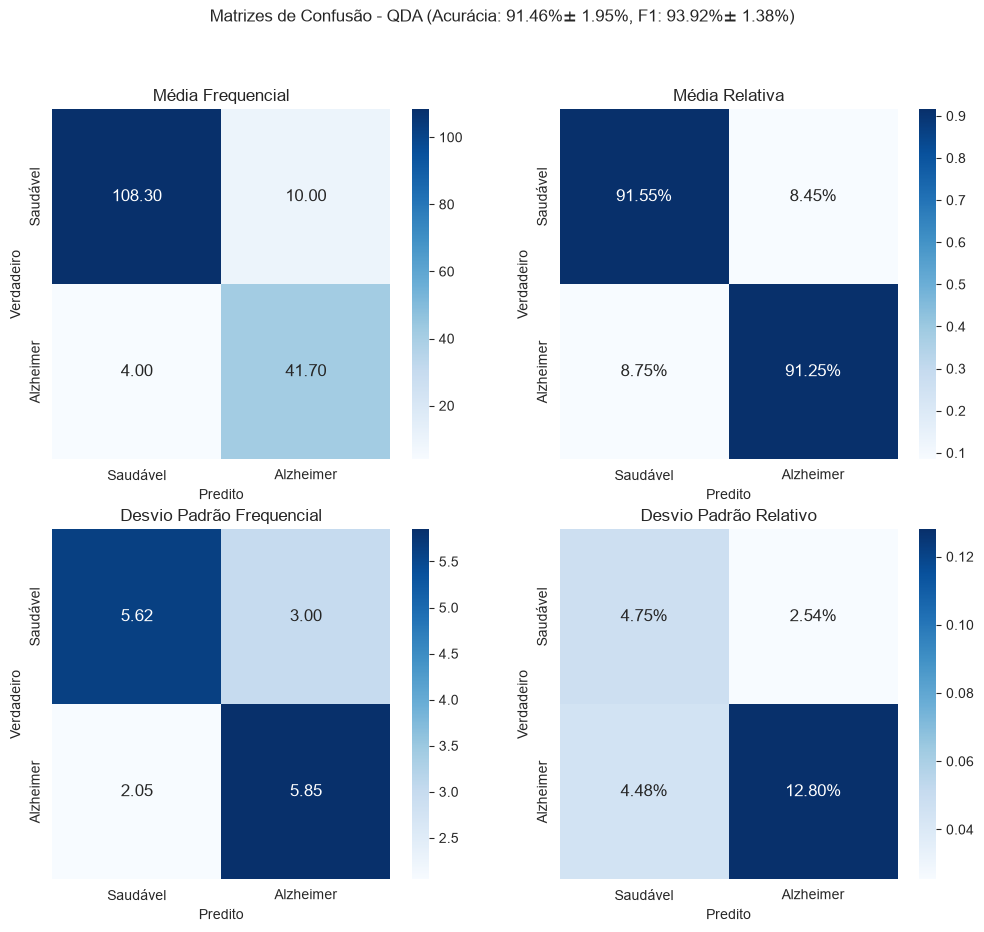

In [30]:
sementes_aleatorias = [42, 7, 21, 84, 100, 123, 456, 789, 101_112, 131_415]

naive_bayes_estocastico = GaussianNB()
lda_estocastico = LinearDiscriminantAnalysis()
qda_estocastico = QuadraticDiscriminantAnalysis()

naive_bayes_resultados = {"acurácias": [], "f1s": [], "matrizes": []}
lda_resultados = {"acurácias": [], "f1s": [], "matrizes": []}
qda_resultados = {"acurácias": [], "f1s": [], "matrizes": []}

for s in sementes_aleatorias:
    # Split
    x_train, x_test, y_train, y_test = train_test_split(dados.drop([COLUNA_CLASSE], axis=1), dados[COLUNA_CLASSE], test_size=0.2, random_state=s, shuffle=True)
    
    # Treino
    naive_bayes_estocastico.fit(x_train, y_train)
    lda_estocastico.fit(x_train, y_train)
    qda_estocastico.fit(x_train, y_train)

    # Teste
    naive_bayes_predicoes = naive_bayes_estocastico.predict(x_test)
    lda_predicoes = lda_estocastico.predict(x_test)
    qda_predicoes = qda_estocastico.predict(x_test)

    # Avaliação - acuracia
    naive_bayes_acuracia = accuracy_score(y_test, naive_bayes_predicoes)
    lda_acuracia = accuracy_score(y_test, lda_predicoes)
    qda_acuracia = accuracy_score(y_test, qda_predicoes)

    # Avaliação - f1
    naive_bayes_f1 = f1_score(y_test, naive_bayes_predicoes, pos_label="Alzheimer")
    lda_f1 = f1_score(y_test, lda_predicoes, pos_label="Alzheimer")
    qda_f1 = f1_score(y_test, qda_predicoes, pos_label="Alzheimer")

    # Armazenamento dos resultados - Naive Bayes
    naive_bayes_resultados["acurácias"].append(naive_bayes_acuracia)
    naive_bayes_resultados["f1s"].append(naive_bayes_f1)
    naive_bayes_resultados["matrizes"].append(confusion_matrix(y_test, naive_bayes_predicoes))

    # Armazenamento dos resultados - LDA
    lda_resultados["acurácias"].append(lda_acuracia)
    lda_resultados["f1s"].append(lda_f1)
    lda_resultados["matrizes"].append(confusion_matrix(y_test, lda_predicoes))

    # Armazenamento dos resultados - QDA
    qda_resultados["acurácias"].append(qda_acuracia)
    qda_resultados["f1s"].append(qda_f1)
    qda_resultados["matrizes"].append(confusion_matrix(y_test, qda_predicoes))

# Resultados
for modelo, resultados in [
    ("Naive Bayes", naive_bayes_resultados), 
    ("LDA", lda_resultados), 
    ("QDA", qda_resultados)
]:
    cm_media = np.mean(resultados["matrizes"], axis=0)
    cm_desvio_padrao = np.std(resultados["matrizes"], axis=0)

    cm_media_relativa = cm_media / cm_media.sum(axis=1)[:, np.newaxis]
    cm_desvio_padrao_relativa = cm_desvio_padrao / cm_media.sum(axis=1)[:, np.newaxis]

    acc_media = np.mean(resultados["acurácias"])
    acc_desvio_padrao = np.std(resultados["acurácias"])
    f1_media = np.mean(resultados["f1s"])
    f1_desvio_padrao = np.std(resultados["f1s"])

    titulo = f"Matrizes de Confusão - {modelo} (Acurácia: {acc_media:.2%}$\\pm$ {acc_desvio_padrao:.2%}, F1: {f1_media:.2%}$\\pm$ {f1_desvio_padrao:.2%})"
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
    hmap_args = {
        "annot": True,
        "cmap": "Blues",
        "xticklabels": ["Saudável", "Alzheimer"],
        "yticklabels": ["Saudável", "Alzheimer"],
        "annot_kws": {"size": 12}
    }
    sns.heatmap(cm_media, ax=axs[0, 0], fmt=".2f",**hmap_args)
    sns.heatmap(cm_media_relativa, ax=axs[0, 1], fmt=".2%", **hmap_args)
    sns.heatmap(cm_desvio_padrao, ax=axs[1, 0], fmt=".2f",**hmap_args)
    sns.heatmap(cm_desvio_padrao_relativa, ax=axs[1, 1], fmt=".2%", **hmap_args)

    axs[0, 0].set_title("Média Frequencial")
    axs[0, 1].set_title("Média Relativa")
    axs[1, 0].set_title("Desvio Padrão Frequencial")
    axs[1, 1].set_title("Desvio Padrão Relativo")

    for ax in axs.flat:
        ax.set_xlabel('Predito')
        ax.set_ylabel('Verdadeiro')
    fig.suptitle(titulo)
    

Tabela das métricas:

In [31]:
df_metricas = pd.DataFrame({
    "Modelo": ["Naive Bayes", "LDA", "QDA"],
    "Acurácia Média": [
        np.mean(naive_bayes_resultados["acurácias"]),
        np.mean(lda_resultados["acurácias"]),
        np.mean(qda_resultados["acurácias"])
    ],
    "Acurácia Desvio Padrão": [
        np.std(naive_bayes_resultados["acurácias"]),
        np.std(lda_resultados["acurácias"]),
        np.std(qda_resultados["acurácias"])
    ],
    "F1 Médio": [
        np.mean(naive_bayes_resultados["f1s"]),
        np.mean(lda_resultados["f1s"]),
        np.mean(qda_resultados["f1s"])
    ],
    "F1 Desvio Padrão": [
        np.std(naive_bayes_resultados["f1s"]),
        np.std(lda_resultados["f1s"]),
        np.std(qda_resultados["f1s"])
    ]
})

display(df_metricas.style.format({
    "Acurácia Média": "{:.2%}",
    "Acurácia Desvio Padrão": "{:.2%}",
    "F1 Médio": "{:.2%}",
    "F1 Desvio Padrão": "{:.2%}"
}))

,Modelo,Acurácia Média,Acurácia Desvio Padrão,F1 Médio,F1 Desvio Padrão
0,Naive Bayes,91.16%,2.08%,93.70%,1.51%
1,LDA,94.15%,1.40%,95.94%,1.02%
2,QDA,91.46%,1.95%,93.92%,1.38%


### Melhor classificador

O LDA obteve as melhores médias de acurácia, F1 e verdadeiro negativo,
mas o QDA obteve as melhores médias de verdadeiro positivo e falso positivo.

O LDA é o classificador com melhor performance ao todo, mas o QDA é o classificador com melhor performance para a classe positiva (Alzheimer).

Dependendo do contexto da aplicação, pode ser mais interessante usar o QDA, mesmo que ele tenha uma performance geral inferior ao LDA.

### Intervalos de confiança 

Como o desvio-padrão real das acurácias enquanto variáveis randômicas é desconhecido, a distribuição t de Student é a mais adequada para auxiliar na dedução dos intervalos de confiança.

Para um processo randômico i.i.d. com $N$ amostras, média amostral $\overline{X}$ e desvio-padrão amostral $s$, tem-se

$$
    \overline{X} - t_{\alpha, \nu} \frac{S}{\sqrt{N}} \leq \mu \leq \overline{X} + t_{\alpha, \nu} \frac{S}{\sqrt{N}}
$$

onde $\alpha$ é o nível de confiança desejado, $\nu=N-1$ a quantidade de graus de liberdade, e $\mu$ a média subjacente de $X$.

Os coeficientes $t_{\alpha, \nu}$ são aproximados numericamente e tabelados para vários $\alpha$ e $\nu$.
Para o caso desta questão, [tem-se](https://en.wikipedia.org/wiki/Student%27s_t-distribution#Table_of_selected_values)

$$
    t_{95\%, 9} = 2.262, \quad
    t_{99.8\%, 9} = 4.297
$$

O código abaixo calcula os intervalos a partir dos resultados do item 7.2 com base na equação e valores acima.

In [32]:
t_95 = 2.262
t_99 = 4.297

for c, t in [(95, t_95), (99.8, t_99)]:
    intervalos = {}
    
    amplitude_naive_bayes = t * np.std(naive_bayes_resultados["acurácias"]) / np.sqrt(len(naive_bayes_resultados["acurácias"]))
    min_naive_bayes = np.mean(naive_bayes_resultados["acurácias"]) - amplitude_naive_bayes
    max_naive_bayes = np.mean(naive_bayes_resultados["acurácias"]) + amplitude_naive_bayes
    intervalo_naive_bayes = (min_naive_bayes, max_naive_bayes, 2*amplitude_naive_bayes)
    
    amplitude_lda = t * np.std(lda_resultados["acurácias"]) / np.sqrt(len(lda_resultados["acurácias"]))
    min_lda = np.mean(lda_resultados["acurácias"]) - amplitude_lda
    max_lda = np.mean(lda_resultados["acurácias"]) + amplitude_lda
    intervalo_lda = (min_lda, max_lda, 2*amplitude_lda)

    amplitude_qda = t * np.std(qda_resultados["acurácias"]) / np.sqrt(len(qda_resultados["acurácias"]))
    min_qda = np.mean(qda_resultados["acurácias"]) - amplitude_qda
    max_qda = np.mean(qda_resultados["acurácias"]) + amplitude_qda
    intervalo_qda = (min_qda, max_qda, 2*amplitude_qda)

    intervalos["Naive Bayes"] = intervalo_naive_bayes
    intervalos["LDA"] = intervalo_lda
    intervalos["QDA"] = intervalo_qda

    display(pd.DataFrame(
        intervalos, 
        index=["Limite Inferior", "Limite Superior", "Delta"]).style.format("{:.2%}").set_caption(
            f"Intervalos de Confiança de {c}% para Acurácia"
        )
    )

,Naive Bayes,LDA,QDA
Limite Inferior,89.67%,93.15%,90.07%
Limite Superior,92.65%,95.14%,92.86%
Delta,2.98%,2.00%,2.79%


,Naive Bayes,LDA,QDA
Limite Inferior,88.33%,92.25%,88.82%
Limite Superior,93.99%,96.04%,94.11%
Delta,5.66%,3.79%,5.29%


O intervalos obtidos corroboram as médias e desvios-padrão médios das acurácias feitas anteriormente, que ranqueavam as médias e desvios como LDA > QDA > Naïve Bayes.

Em particular, os intervalos do LDA são mais estreitos que os do QDA, que por sua vez são similares em largura aos do Naïve Bayes, o que indica que o LDA é o classificador mais confiável entre os três.
Isso provavelmente se deve ao fato de que o LDA é um modelo mais simples, com menos parâmetros a serem estimados, e portanto menos suscetível a variações nos dados de treino.
O QDA, por outro lado, é um modelo mais complexo, com mais parâmetros a serem estimados, e portanto mais suscetível a variações nos dados de treino.
Em paralelo, o Naïve Bayes é um modelo simples, mas com forte suposição de independência entre as features, o que não é verdade para vários pares de features deste dataset.